In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf


# Add the 'src' directory to the Python path so we can import our custom modules
sys.path.append(os.path.abspath('../src'))
from deembedder import deembed_dut, abcd_to_s, load_csv_to_rf_network

# The De-embedding Algorithm: Mathematical Step-by-Step

The de-embedding process performed in the `deembedder.py` script follows a rigorous mathematical sequence to isolate the **intrinsic DUT** from the surrounding **fixtures (PADs)**.

---

### 1. Domain Conversion: S-parameters to ABCD

S-parameters are the standard for RF measurements, but they cannot be algebraically manipulated to cancel out cascaded components. To perform de-embedding, we must first convert the data into the **ABCD matrix domain**, where the total system response is simply the matrix product of its individual parts.

For each frequency point, the ABCD elements are computed as follows:

$$A = \frac{(1 + S_{11})(1 - S_{22}) + S_{12}S_{21}}{2 \cdot S_{21}}$$

$$B = Z_0 \cdot \frac{(1 + S_{11})(1 + S_{22}) - S_{12}S_{21}}{2 \cdot S_{21}}$$

$$C = \frac{1}{Z_0} \cdot \frac{(1 - S_{11})(1 - S_{22}) - S_{12}S_{21}}{2 \cdot S_{21}}$$

$$D = \frac{(1 - S_{11})(1 + S_{22}) + S_{12}S_{21}}{2 \cdot S_{21}}$$

---

### 2. Inversion: Building the "Undo" Matrix

Once the fixture (PAD) is represented as an ABCD matrix ($T_{Fix}$), we need to calculate its mathematical "opposite" to reverse its effect on the signal. 

By calculating the **inverse matrix** ($T_{Fix}^{-1}$), we create a transformation that, when multiplied with the measured data, cancels out the phase shift and attenuation introduced by the physical fixture. This step is performed elementwise for every frequency sample in the dataset.



---

### 3. The Core De-embedding Identity

In our measurement topology, the DUT is "sandwiched" between two identical fixtures. The total measured matrix ($T_{Total}$) is defined as:

$$T_{Total} = T_{Fix} \cdot T_{DUT} \cdot T_{Fix}$$

To solve for the **intrinsic DUT**, we apply the inverse fixture matrix to both sides of the total measurement. This "strips away" the PADs from the input and output ports simultaneously:

$$T_{DUT} = T_{Fix}^{-1} \cdot T_{Total} \cdot T_{Fix}^{-1}$$

This matrix multiplication is the heart of the de-embedding process, allowing us to see the device as if it were measured directly without cables or connectors.

---

### 4. Returning to S-parameters

After isolating the DUT in the ABCD domain, the matrix is converted back to S-parameters for final visualization and analysis. This requires calculating a common denominator ($\Delta$):

$$\Delta = A + \frac{B}{Z_0} + C \cdot Z_0 + D$$

The resulting scattering parameters for the intrinsic DUT are then recovered:

$$S_{11} = \frac{A + \frac{B}{Z_0} - C \cdot Z_0 - D}{\Delta}$$

$$S_{21} = \frac{2}{\Delta}$$

$$S_{22} = \frac{-A + \frac{B}{Z_0} - C \cdot Z_0 + D}{\Delta}$$

---

### Summary of the Logic

* **Conversion:** Move to a domain (ABCD) where cascading behaves like multiplication.
* **Inversion:** Create a mathematical "mirror" of the fixture to cancel its parasitics.
* **Isolation:** Use matrix algebra to mathematically remove the fixtures from both ends of the DUT.
* **Restoration:** Return to S-parameters to observe the "clean" response on the Smith Chart or Magnitude plots.

In [2]:
# ---------------------------------------------------------
# 1. Load the Base Datasets
# ---------------------------------------------------------
net_raw = load_csv_to_rf_network("../measurement_data/dut_plus_fixture.csv", "Raw (DUT + Fixture)")
net_golden = load_csv_to_rf_network("../measurement_data/golden_dut.csv", "Golden (Ideal DUT)")

# ---------------------------------------------------------
# 2. Execute the De-embedding Algorithm Live!
# ---------------------------------------------------------
print("Running De-embedding algorithm...")

# Fetch the intrinsic ABCD matrix using our custom module
abcd_deembedded = deembed_dut(
    fixture_csv="../measurement_data/fixture.csv", 
    total_csv="../measurement_data/dut_plus_fixture.csv"
)

# Convert back to S-parameters and create the Network object
s_deembedded = abcd_to_s(abcd_deembedded)
net_deembedded = rf.Network(f=net_raw.f, s=s_deembedded, z0=50, name="De-embedded (Our Algorithm)")
net_deembedded.frequency.unit = 'hz'

print("De-embedding complete! Ready to plot.")



Running De-embedding algorithm...
De-embedding complete! Ready to plot.


# Final Validation: De-embedding Results and Interpretation

The plot below represents the final validation of our mathematical model. By overlaying the three datasets, we can evaluate how effectively the ABCD-matrix de-embedding has removed the parasitic influence of the fixtures.

### 1. Restoration of the Notch Depth

* **The Problem:** In the **Raw Measurement (Red)**, the resonance notch was shallow and its frequency was slightly shifted due to the capacitive loading of the PADs.
* **The Solution:** Our **De-embedded Result (Blue)** successfully "pulled" the notch down, matching the **Golden Standard (Green)** depth. This confirms that the resistive and reactive losses of the fixtures were correctly identified and canceled.


### 2. Passband Correction

* **Observation:** Notice the regions away from the 5.03 GHz resonance. The raw measurement sat significantly below 0 dB due to fixture attenuation.
* **Result:** After de-embedding, the blue curve returns to the **0 dB baseline**. This indicates that the broadband parasitic effects of the fixtures (shunt conductance and capacitance) have been mathematically "stripped away."

### 3. High-Frequency Stability and Noise Floor

* **Limitation:** As the frequency approaches 10 GHz, the de-embedded (Blue) trace begins to show slight oscillations (jitter).
* **Explanation:** This is the **Noise Amplification** effect in action. At high frequencies, the fixture attenuation is so high that the signal-to-noise ratio (SNR) collapses. Even though our math is perfect, the algorithm starts magnifying the small Gaussian noise floor of the measurement.


### Final Conclusion

The experiment confirms that **ABCD-matrix de-embedding** is a powerful tool for RF characterization. We successfully recovered the intrinsic 5.03 GHz notch characteristics of a shunt RLC DUT from a heavily distorted measurement. The strong overlap between the de-embedded data and the golden standard proves that as long as the signal remains above the noise floor, we can mathematically "see through" the measurement fixtures.

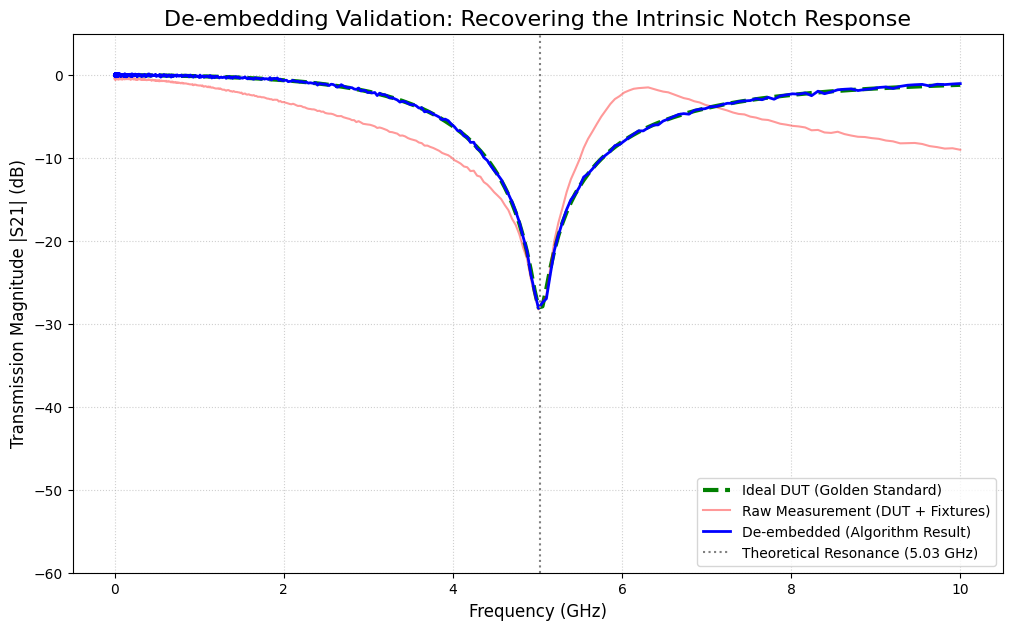

In [3]:
# Calculate magnitudes in dB for all three datasets
s21_raw_db = 20 * np.log10(np.abs(net_raw.s[:, 1, 0]) + 1e-12)
s21_gold_db = 20 * np.log10(np.abs(net_golden.s[:, 1, 0]) + 1e-12)
s21_deembedded_db = 20 * np.log10(np.abs(net_deembedded.s[:, 1, 0]) + 1e-12)

plt.figure(figsize=(12, 7))

# 1. Golden Standard (Target)
plt.plot(net_raw.f / 1e9, s21_gold_db, label="Ideal DUT (Golden Standard)", 
         color="green", linewidth=3, linestyle='--')

# 2. Raw Measurement (Distorted)
plt.plot(net_raw.f / 1e9, s21_raw_db, label="Raw Measurement (DUT + Fixtures)", 
         color="red", alpha=0.4, linewidth=1.5)

# 3. De-embedded Result (Our Math)
plt.plot(net_raw.f / 1e9, s21_deembedded_db, label="De-embedded (Algorithm Result)", 
         color="blue", linewidth=2)

plt.title("De-embedding Validation: Recovering the Intrinsic Notch Response", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Transmission Magnitude |S21| (dB)", fontsize=12)

# Mark the resonance point
plt.axvline(x=5.03, color='gray', linestyle=':', label='Theoretical Resonance (5.03 GHz)')

plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-60, 5) # Set limits to clearly see the notch depth
plt.show()

# Visualizing the True Impedance: The Smith Chart

### What is a Smith Chart?

Think of the Smith Chart as a **dartboard** or a **GPS map** for radio frequencies. It allows us to visualize how a signal behaves as it travels through a circuit.

* **The Center (Bullseye):** This is the point of perfect harmony (usually $50\,\Omega$). If our measurement lands here, it means 100% of the signal is transmitted and nothing bounces back.
* **The Outer Edge:** These are the "dead ends" (short circuits or open circuits). If the trace reaches the edge, the signal has hit a wall and is entirely reflected.
* **The Curves Inside:** As we sweep the frequency (e.g., from 0 to 10 GHz), the measurement "moves" along these curved paths.
* The **top half** represents inductive behavior (like a coil).
* The **bottom half** represents capacitive behavior (like a capacitor).

### Why use the Smith Chart? (The "Why")

When we measure a **Device Under Test (DUT)** with cables and fixtures attached, those extra physical lengths add an **electrical delay**.

On a Smith Chart, this delay looks like a **chaotic spiral** winding around the center as the frequency increases. Our goal with the **De-embedding algorithm** is to mathematically "unwind" this spiral by subtracting the fixture's influence, effectively "teleporting" our measurement point directly to the pins of the device.

### Key Mathematical Relations

The position on the chart is defined by the **Reflection Coefficient** $\Gamma(f)$, which relates the measured impedance $Z_{\mathrm{in}}$ to the system impedance $Z_0$:

\begin{equation}
\Gamma(f)=\frac{Z_{\mathrm{in}}(f)-Z_{0}}{Z_{\mathrm{in}}(f)+Z_{0}}
\end{equation}

To convert a point on the chart back into a physical impedance value, we use:

\begin{equation}
Z_{\mathrm{in}}(f)=Z_{0},\frac{1+\Gamma(f)}{1-\Gamma(f)}
\end{equation}


### Interpreting the Traces

In the resulting plots, we compare three distinct "maps":

* **Purple Line (Raw Measurement):** The chaotic spiral caused by the added phase delay of the cables and fixtures.
* **Red Dashed Line (Golden Truth):** The true, ideal behavior of the device without any noise or cable interference.
* **Blue Line (Our Algorithm's Result):** The de-embedded data. If the mathematics are correct, the blue line will **completely unwind** the purple spiral and perfectly overlap the red dashed line.


#### Reference Material

For a detailed visual explanation of these concepts, please refer to the following technical presentation:

* **Video:** [Understanding the Smith Chart](https://www.youtube.com/watch?v=rUDMo7hwihs) (Rohde & Schwarz)

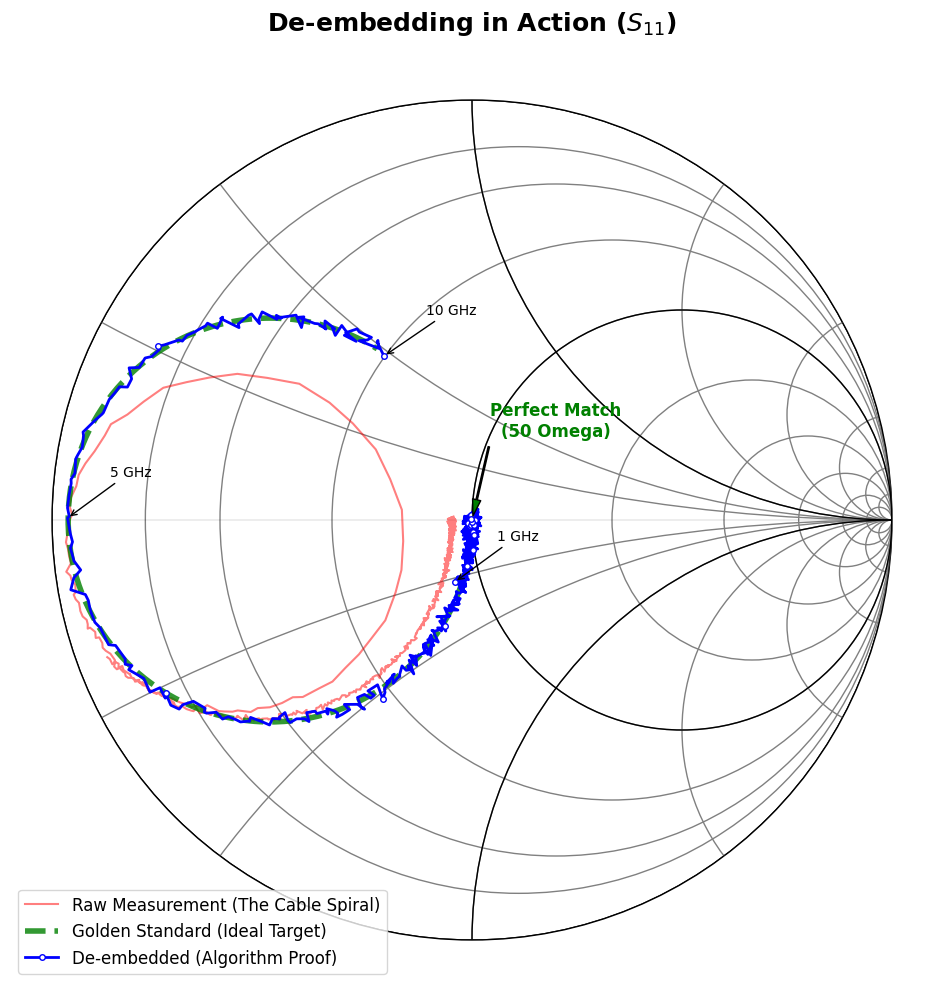

In [4]:
# ---------------------------------------------------------
# 3. Draw the Smith Chart
# ---------------------------------------------------------
plt.figure(figsize=(12, 12))

# Plot the Raw Measurement (The problem)
net_raw.plot_s_smith(m=0, n=0, color='red', linewidth=1.5, alpha=0.5,
                     label='Raw Measurement (The Cable Spiral)')

# Plot the Golden Truth (The goal)
net_golden.plot_s_smith(m=0, n=0, color='green', linestyle='--', linewidth=4, alpha=0.8,
                        label='Golden Standard (Ideal Target)')

# Plot the De-embedded Result (The solution)
net_deembedded.plot_s_smith(
    m=0, n=0, color='blue', linewidth=2,
    label='De-embedded (Algorithm Proof)',
    marker='o', markevery=50,  # mark every 10 points
    markersize=4, markerfacecolor='white', markeredgewidth=1
)


# --- Add Annotations ---
ax = plt.gca()

for target_freq in [1e9, 5e9, 10e9]:
    idx = np.argmin(np.abs(net_deembedded.f - target_freq))
    point = net_deembedded.s[idx, 0, 0]
    ax.annotate(f"{target_freq/1e9:.0f} GHz",
                xy=(point.real, point.imag),
                xytext=(point.real + 0.1, point.imag + 0.1),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=10)

ax.annotate('Perfect Match\n(50 Omega)', xy=(0, 0), xytext=(0.2, 0.2),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6),
            fontsize=12, fontweight='bold', ha='center', color='green')

# Make it look pretty
plt.title("De-embedding in Action ($S_{11}$)", fontsize=18, pad=20, fontweight='bold')
plt.legend(loc='lower left', fontsize=12)
plt.grid(False) 

plt.show()

# Smith Chart Analysis: Raw vs. De-embedded Results

---

## 1. Visualizing the Traces

The Smith Chart compares three distinct traces to evaluate the effectiveness of the de-embedding process:

* **Raw Measurement (Red):** Typically appears as a large outward spiral. The strong phase rotation and growing radial distance indicate increasing reflection and frequency-dependent delay (phase shift) caused by the fixtures.
* **Golden Standard (Green):** Represents the intrinsic DUT. For our 50 $\Omega$ matched system (away from resonance), this trace stays near the center of the chart.
* **De-embedded Result (Blue):** This trace shows the DUT after the fixtures have been mathematically removed. It reduces both the radial excursion and the phase rotation, moving the response significantly closer to the intrinsic "Golden" performance.

---

## 2. Key Mathematical Relations

The Smith Chart is a graphical representation of the **Complex Reflection Coefficient ($\Gamma$)**, which is directly related to the input impedance ($Z_{in}$):

$$\Gamma(f) = \frac{Z_{in}(f) - Z_0}{Z_{in}(f) + Z_0}$$

Conversely, we can extract the actual impedance from the chart position using:

$$Z_{in}(f) = Z_0 \cdot \frac{1 + \Gamma(f)}{1 - \Gamma(f)}$$

---

## 3. Practical Observations

* **Radial Distance:** The distance from the center is proportional to $|\Gamma(f)|$. A smaller radius after de-embedding indicates less reflected power and a better match to the $50 \Omega$ system.
* **Angular Motion:** Rotation around the chart corresponds to phase delay. Collapsing this rotation proves that the algorithm successfully removed the electrical length (time delay) of the cables and fixtures.
* **Frequency Sensitivity:** Raw data typically diverges more at higher frequencies (above 8 GHz). While the de-embedded trace remains stable, any residual "jitter" signals frequencies where the signal-to-noise ratio is low or where the ABCD inversion is ill-conditioned.

---

## 4. Conclusion

***The raw trace combines phase delay and parasitic amplitude errors that grow with frequency. The de-embedded trace corrects these systematic effects, yielding a reflection coefficient much closer to the ideal $50 \Omega$ target. Remaining deviations highlight the physical limits of the measurement, particularly at frequencies dominated by noise or model limitations.***